<a href="https://colab.research.google.com/github/Ironman20121/Colabfiles/blob/main/assingment_BI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# !rm -rf /content/*
# !ls -lrt /content/* | wc -l

14


In [ ]:
df_alien = pd.read_excel('/content/AlienSwirlingSaucers_215_valid.xlsx')
print("all dublicates rows count ",df_alien.duplicated().sum(),sep=":")
df_alien = df_alien.drop_duplicates()
print("removed == 0 ",df_alien.duplicated().sum(),sep=":")

all dublicates rows count :520
removed == 0 :0


In [ ]:
df = df_alien.copy()
print(f"""
info :
{df.info()}
details :
{df.describe()}
head :
{df.head()}
""")


<class 'pandas.core.frame.DataFrame'>
Index: 316514 entries, 0 to 317033
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   actual_opening_time_eastern  316514 non-null  object        
 1   closing_time_eastern         316514 non-null  object        
 2   observation_time_eastern     316514 non-null  datetime64[ns]
 3   estimated_wait               316514 non-null  int64         
 4   actual_wait                  4901 non-null    float64       
 5   park_day                     316514 non-null  object        
 6   mins_since_emh_open          316514 non-null  int64         
 7   avg_wait_this_day            316514 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 21.7+ MB

info : 
None
details : 
            observation_time_eastern  estimated_wait  actual_wait  \
count                         316514   316514.000000  4901.

In [ ]:
df.isnull().sum()

,0
actual_opening_time_eastern,0
closing_time_eastern,0
observation_time_eastern,0
estimated_wait,0
actual_wait,311613
park_day,0
mins_since_emh_open,0
avg_wait_this_day,0


## About AlienSwirlingSaucers file

- as we see actual waiting time is have lot of missing values and we cannot calulate  actual waitng time from other inputs we are removing it .

- other way we can genreate Synthetic data using ml still we can avoid it



In [ ]:
df = df_alien.copy()
df = df.drop(columns=['actual_wait'])
df_alien = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 316514 entries, 0 to 317033
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   actual_opening_time_eastern  316514 non-null  object        
 1   closing_time_eastern         316514 non-null  object        
 2   observation_time_eastern     316514 non-null  datetime64[ns]
 3   estimated_wait               316514 non-null  int64         
 4   park_day                     316514 non-null  object        
 5   mins_since_emh_open          316514 non-null  int64         
 6   avg_wait_this_day            316514 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 19.3+ MB


In [ ]:
df_meta = pd.read_csv("/content/current_metatable.csv")
# Merge DataFrames:
# Merge the ride data with the metadata DataFrame using the "park_day" column.
df_merged = pd.merge(df_meta, df, left_on='DATE', right_on='park_day')
df_merged.DATE = pd.to_datetime(df_merged.DATE)
df_merged['day_of_week'] = df_merged.DATE.dt.day_name()
df_merged.head()


<ipython-input-18-25e4fc557c25>:1: DtypeWarning: Columns (74,76,83,100,105,106,107,117,118,119,134,135,136,139,160,169,170,171,177,178,179,192,197,198,199,201,202,203,205,206,207,209,210,211,271,291,292,293,294) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv("/content/current_metatable.csv")


,DATE,MKOPEN,MKCLOSE,MKHOURS,MKHOURSEMH,MKEMHOPEN,MKEMHMORN,MKEMHMYEST,MKEMHMTOM,MKEMHCLOSE,...,DLRPRICEFACTOR,UORPRICEFACTOR,actual_opening_time_eastern,closing_time_eastern,observation_time_eastern,estimated_wait,park_day,mins_since_emh_open,avg_wait_this_day,day_of_week
0,2018-06-30,08:00,22:00,14.0,14.0,NaN,0,0,0,NaN,...,1.0,1.0,2018-06-30 08:00,2018-06-30 23:00,2018-06-30 07:44:00,150,2018-06-30,464,128.787879,Saturday
1,2018-06-30,08:00,22:00,14.0,14.0,NaN,0,0,0,NaN,...,1.0,1.0,2018-06-30 08:00,2018-06-30 23:00,2018-06-30 07:51:00,150,2018-06-30,471,128.787879,Saturday
2,2018-06-30,08:00,22:00,14.0,14.0,NaN,0,0,0,NaN,...,1.0,1.0,2018-06-30 08:00,2018-06-30 23:00,2018-06-30 07:58:00,150,2018-06-30,478,128.787879,Saturday
3,2018-06-30,08:00,22:00,14.0,14.0,NaN,0,0,0,NaN,...,1.0,1.0,2018-06-30 08:00,2018-06-30 23:00,2018-06-30 08:02:00,150,2018-06-30,482,128.787879,Saturday
4,2018-06-30,08:00,22:00,14.0,14.0,NaN,0,0,0,NaN,...,1.0,1.0,2018-06-30 08:00,2018-06-30 23:00,2018-06-30 08:07:00,150,2018-06-30,487,128.787879,Saturday


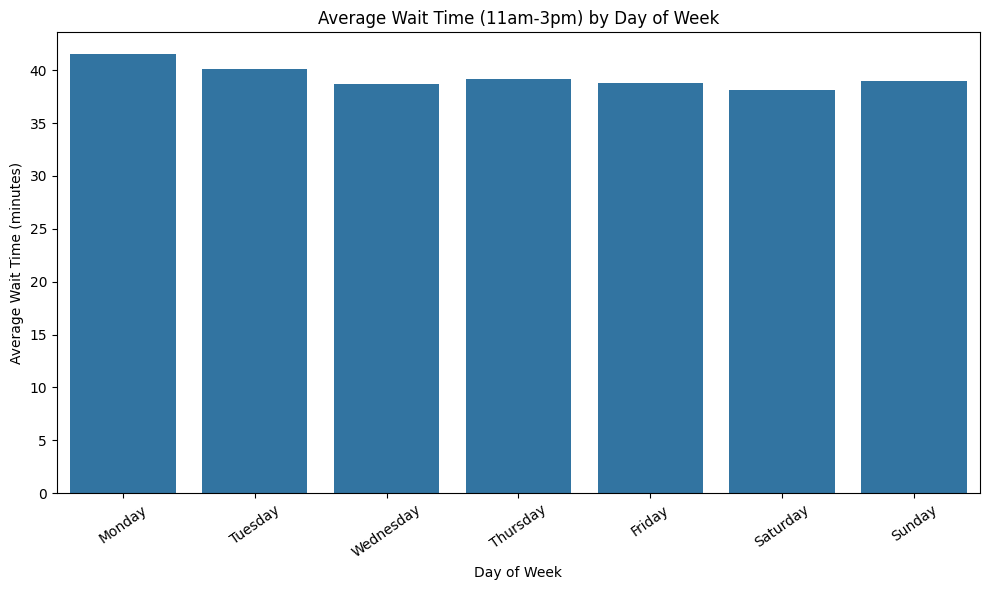

In [ ]:
avg_wait_by_day = df_merged.groupby('day_of_week')['avg_wait_this_day'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
# Create the graph
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_wait_by_day.index, y=avg_wait_by_day.values)
plt.title('Average Wait Time (11am-3pm) by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Wait Time (minutes)')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

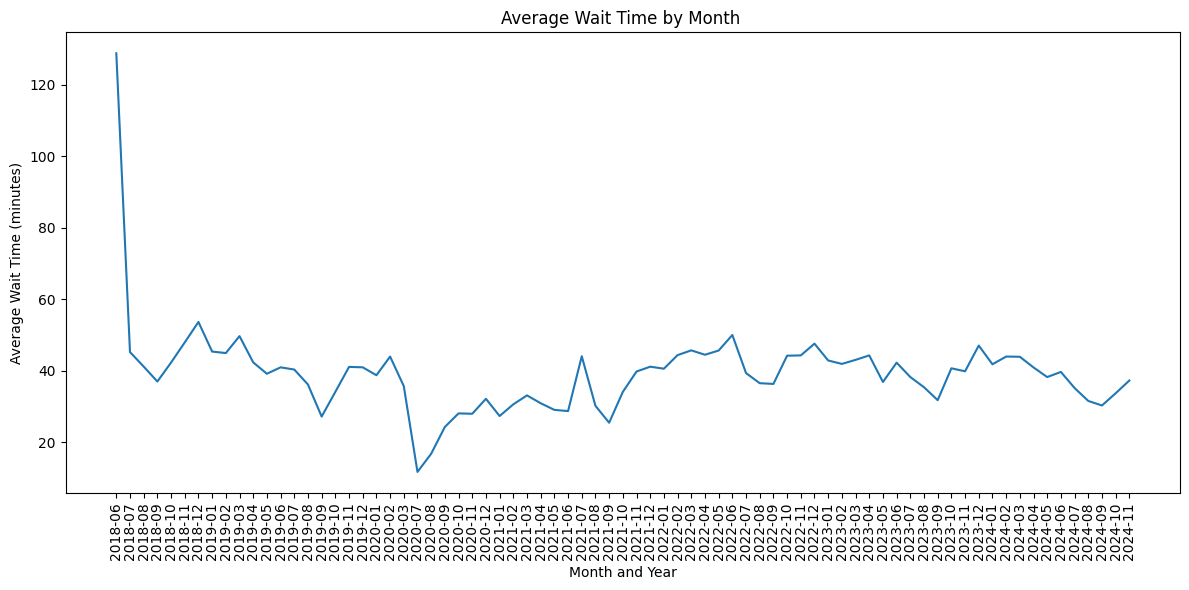

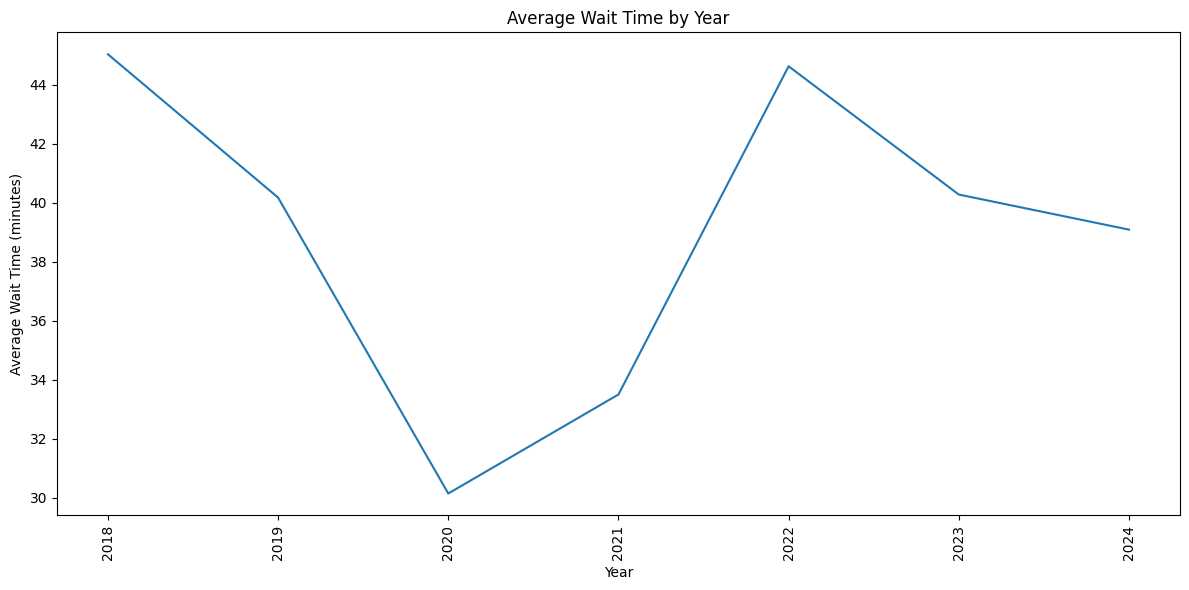

In [ ]:
# Convert park_day to datetime
df_merged['park_day'] = pd.to_datetime(df_merged['park_day'])

# Convert observation_time_eastern to datetime
df_merged['observation_time_eastern'] = pd.to_datetime(df_merged['observation_time_eastern'])

# Handle missing actual_wait values
# df_merged['actual_wait'].fillna(method='ffill', inplace=True)


# Function to plot average wait times over time
def plot_avg_wait_time(df, time_unit, title, x_label, date_format=None):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=time_unit, y='avg_wait_this_day', data=df)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel('Average Wait Time (minutes)')
    if date_format:
        plt.gca().xaxis.set_major_formatter(date_format)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Plot average wait time by month
df_month = df_merged.copy()
df_month['month_year'] = df_month['park_day'].dt.to_period('M')  # Group by month and year
avg_wait_month = df_month.groupby('month_year')['avg_wait_this_day'].mean().reset_index()
avg_wait_month['month_year'] = avg_wait_month['month_year'].astype(str)  # Convert to string for plotting
plot_avg_wait_time(avg_wait_month, 'month_year', 'Average Wait Time by Month ', 'Month and Year')

# Plot average wait time by year
df_year = df_merged.copy()
df_year['year'] = df_year['park_day'].dt.year
avg_wait_year = df_year.groupby('year')['avg_wait_this_day'].mean().reset_index()
plot_avg_wait_time(avg_wait_year, 'year', 'Average Wait Time by Year', 'Year')

- Q1 does weekend or weekdays diff on watingn time ? anwer is no
- Q2 which year or month wating time is low ?

In [ ]:
df_downt = pd.read_excel("/content/2023_ride_downtime.xlsx")
df_downt.drop_duplicates()
for i in df_downt.columns:
  if i not in ['Unnamed: 0','Day of Week','HS-Alien Saucers']:
    df_downt.drop(columns=[i],inplace=True)

df_downt = df_downt.rename(columns={'Unnamed: 0':'park_day'})

df_downt = df_downt[df_downt['HS-Alien Saucers']!=0]
df_downt = df_downt.loc[2:]
df_downt.info()


<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 2 to 382
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   park_day          81 non-null     object 
 1   Day of Week       81 non-null     object 
 2   HS-Alien Saucers  81 non-null     float64
dtypes: float64(1), object(2)
memory usage: 3.0+ KB


In [ ]:
df_downt.park_day=pd.to_datetime(df_downt.park_day)
df_downt.park_day=df_downt.park_day.dt.date
df_alien.park_day = pd.to_datetime(df_alien.park_day)
df_alien.park_day = df_alien.park_day.dt.date

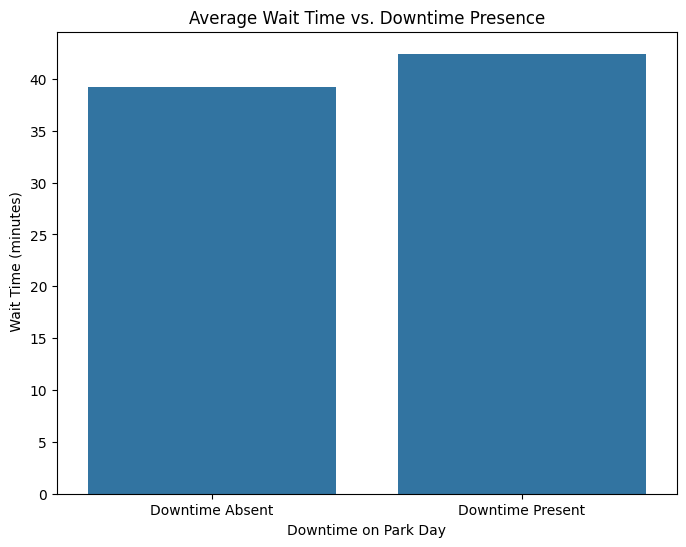

downtime_present
False    39.163140
True     42.416842
Name: avg_wait_this_day, dtype: float64


In [ ]:
# Create a 'downtime_present' column in df_alien
df_alien['downtime_present'] = df_alien['park_day'].isin(df_downt['park_day'])

# Group and calculate average wait time
grouped_wait = df_alien.groupby('downtime_present')['avg_wait_this_day'].mean()

# Plotting the results
plt.figure(figsize=(8, 6))
sns.barplot(x=grouped_wait.index.astype(str), y=grouped_wait.values)
plt.title('Average Wait Time vs. Downtime Presence')
plt.xlabel('Downtime on Park Day')
plt.ylabel(' Wait Time (minutes)')
plt.xticks([0, 1], ['Downtime Absent', 'Downtime Present'])  # Set custom labels
plt.show()

# Print the grouped data for numerical values
print(grouped_wait)


Q3 Does downtime impacts waiting time ? yes as it is 42 perset fact is it only downtime is only of 2023

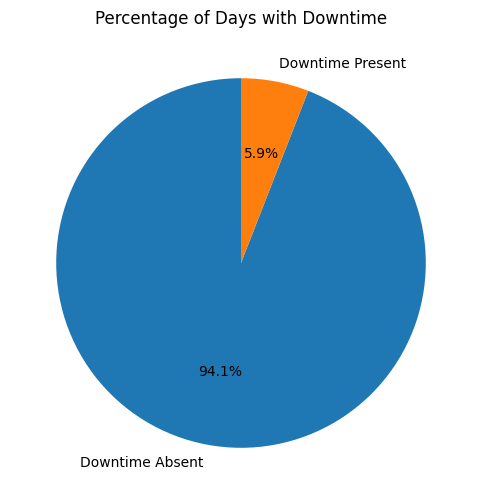

downtime_present
False    94.07072
True      5.92928
Name: count, dtype: float64


In [ ]:
# Create a 'downtime_present' column in df_alien
df_alien['downtime_present'] = df_alien['park_day'].isin(df_downt['park_day'])

# Group and calculate counts
downtime_counts = df_alien['downtime_present'].value_counts()

# Calculate percentages
total_days = downtime_counts.sum()
percentages = (downtime_counts / total_days) * 100

# Plotting the results as a pie chart
plt.figure(figsize=(8, 6))
plt.pie(percentages, labels=['Downtime Absent', 'Downtime Present'], autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Days with Downtime')
plt.show()

# Print the percentages for numerical values
print(percentages)

In [ ]:
#! /bin/env python3

######################################################################
# last Updates line :
# last Updates date :
######################################################################

#########################IMPORTS#######################################
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#####################################################################


def eda(s: str):

    df = pd.DataFrame()

    try:
        df = pd.read_excel(s) if s[-3:] != 'csv' else pd.read_csv(s)
        # remove duplicates and unnecessary col
        df = df.drop_duplicates()
        df = df.drop(columns=['actual_wait'])
        df_meta = pd.read_csv('/content/current_metatable.csv')
        df_merged = pd.merge(df_meta, df, left_on='DATE', right_on='park_day')
        df_merged.DATE = pd.to_datetime(df_merged.DATE)
        df_merged['day_of_week'] = df_merged.DATE.dt.day_name()

        # graph 1 weekdays vs weekends Q1
        avg_wait_by_day = df_merged.groupby('day_of_week')['avg_wait_this_day'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
        plt.figure(figsize=(10, 6))
        sns.barplot(x=avg_wait_by_day.index, y=avg_wait_by_day.values)
        plt.title('Average Wait Time (11am-3pm) by Day of Week')
        plt.xlabel('Day of Week')
        plt.ylabel('Average Wait Time (minutes)')
        plt.xticks(rotation=35)
        plt.tight_layout()
        plt.show()

        # Convert park_day & other date times to datetime
        df_merged['park_day'] = pd.to_datetime(df_merged['park_day'])
        df_merged['observation_time_eastern'] = pd.to_datetime(df_merged['observation_time_eastern'])

        # Function to plot average wait times over time
        def plot_avg_wait_time(df, time_unit, title, x_label, date_format=None):
            plt.figure(figsize=(12, 6))
            sns.lineplot(x=time_unit, y='avg_wait_this_day', data=df)
            plt.title(title)
            plt.xlabel(x_label)
            plt.ylabel('Average Wait Time (minutes)')
            if date_format:
                plt.gca().xaxis.set_major_formatter(date_format)
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()

        # Plot average wait time by month Question 2
        df_month = df_merged.copy()
        df_month['month_year'] = df_month['park_day'].dt.to_period('M')  # Group by month and year
        avg_wait_month = df_month.groupby('month_year')['avg_wait_this_day'].mean().reset_index()
        avg_wait_month['month_year'] = avg_wait_month['month_year'].astype(str)  # Convert to string for plotting
        plot_avg_wait_time(avg_wait_month, 'month_year', 'Average Wait Time by Month ', 'Month and Year')

        # Plot average wait time by year Question 2
        df_year = df_merged.copy()
        df_year['year'] = df_year['park_day'].dt.year
        avg_wait_year = df_year.groupby('year')['avg_wait_this_day'].mean().reset_index()
        plot_avg_wait_time(avg_wait_year, 'year', 'Average Wait Time by Year', 'Year')

        df_downt = pd.read_excel("/content/2023_ride_downtime.xlsx")
        df_downt.drop_duplicates()
        for i in df_downt.columns:
            if i not in ['Unnamed: 0', 'Day of Week', 'HS-Alien Saucers']:
                df_downt.drop(columns=[i], inplace=True)
        df_downt = df_downt.rename(columns={'Unnamed: 0': 'park_day'})
        df_downt = df_downt[df_downt['HS-Alien Saucers'] != 0]
        df_downt = df_downt.loc[2:]
        df_downt.info()
        df_downt.park_day = pd.to_datetime(df_downt.park_day)
        df_downt.park_day = df_downt.park_day.dt.date
        df.park_day = pd.to_datetime(df.park_day)
        df.park_day = df.park_day.dt.date

        # Create a 'downtime_present' column in df
        df['downtime_present'] = df['park_day'].isin(df_downt['park_day'])

        # Group and calculate average wait time
        grouped_wait = df.groupby('downtime_present')['avg_wait_this_day'].mean()
        # Plotting the results
        plt.figure(figsize=(8, 6))
        sns.barplot(x=grouped_wait.index.astype(str), y=grouped_wait.values)
        plt.title('Average Wait Time vs. Downtime Presence')
        plt.xlabel('Downtime on Park Day')
        plt.ylabel(' Wait Time (minutes)')
        plt.xticks([0, 1], ['Downtime Absent', 'Downtime Present'])  # Set custom labels
        plt.show()

        """Q3 Does downtime impacts waiting time ? yes as it is 42 perset fact is it only downtime is only of 2023"""
        # Create a 'downtime_present' column in df_alien
        df['downtime_present'] = df['park_day'].isin(df_downt['park_day'])
        # Group and calculate counts
        downtime_counts = df['downtime_present'].value_counts()
        # Calculate percentages
        total_days = downtime_counts.sum()
        percentages = (downtime_counts / total_days) * 100
        # showing data not use full for data analysis because we only 2023 downtime date
        # Plotting the results as a pie chart
        plt.figure(figsize=(8, 6))
        plt.pie(percentages, labels=['Downtime Absent', 'Downtime Present'], autopct='%1.1f%%', startangle=90)
        plt.title('Percentage of Days with Downtime')
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")



<ipython-input-22-edabf6b3a514>:24: DtypeWarning: Columns (74,76,83,100,105,106,107,117,118,119,134,135,136,139,160,169,170,171,177,178,179,192,197,198,199,201,202,203,205,206,207,209,210,211,271,291,292,293,294) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv('/content/current_metatable.csv')


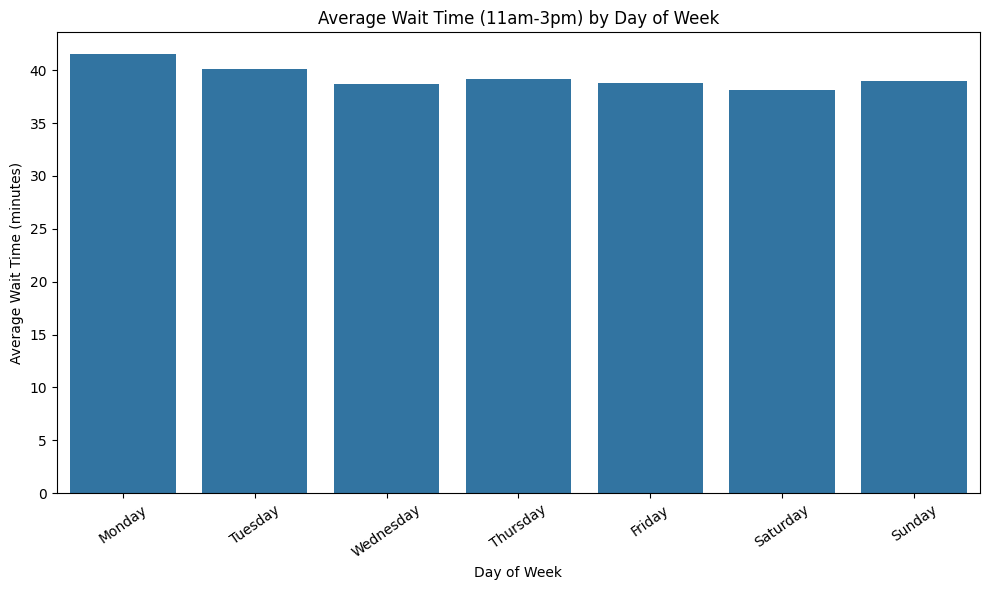

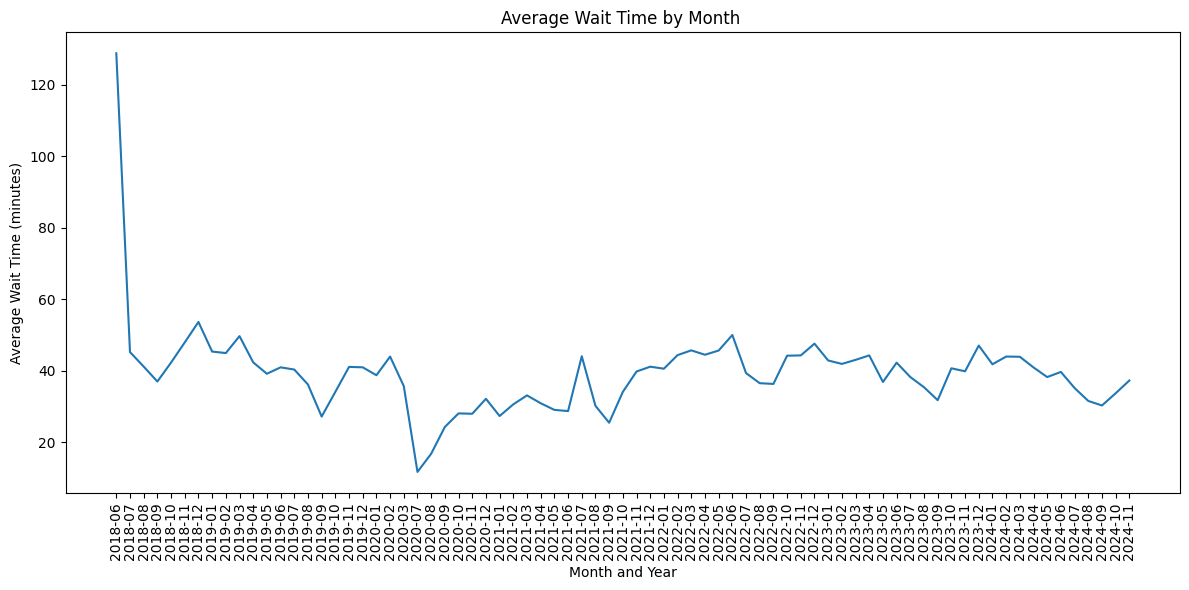

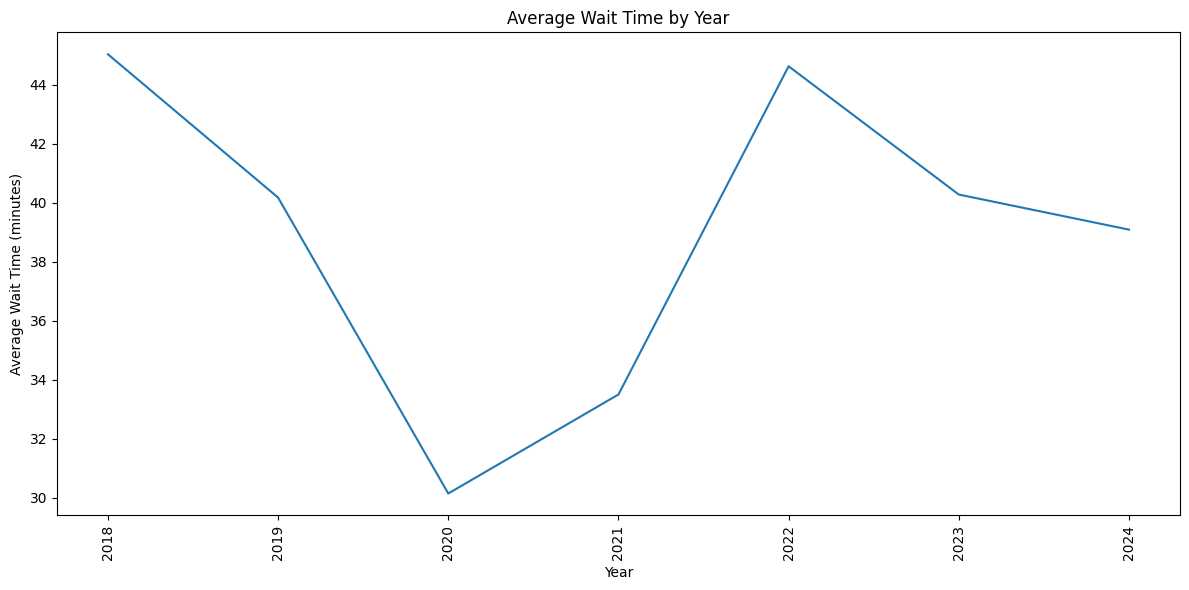

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 2 to 382
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   park_day          81 non-null     object 
 1   Day of Week       81 non-null     object 
 2   HS-Alien Saucers  81 non-null     float64
dtypes: float64(1), object(2)
memory usage: 3.0+ KB


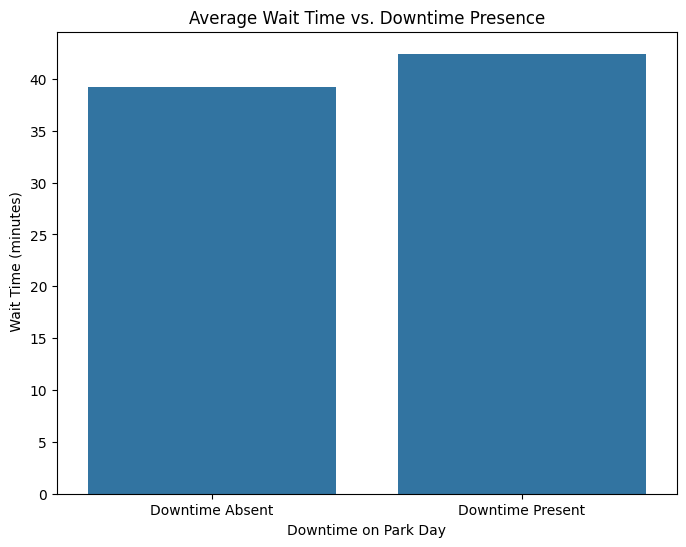

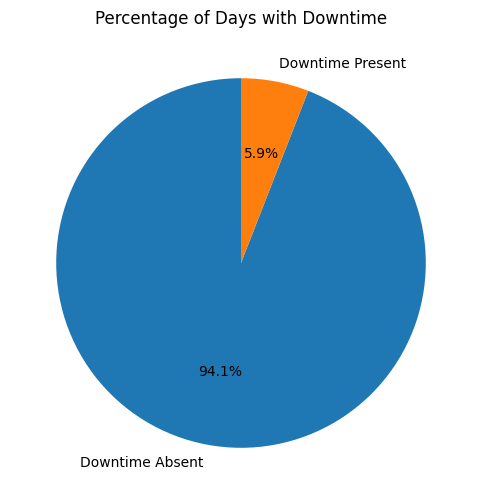

In [ ]:
eda('/content/AlienSwirlingSaucers_215_valid.xlsx')

<ipython-input-22-edabf6b3a514>:24: DtypeWarning: Columns (74,76,83,100,105,106,107,117,118,119,134,135,136,139,160,169,170,171,177,178,179,192,197,198,199,201,202,203,205,206,207,209,210,211,271,291,292,293,294) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv('/content/current_metatable.csv')


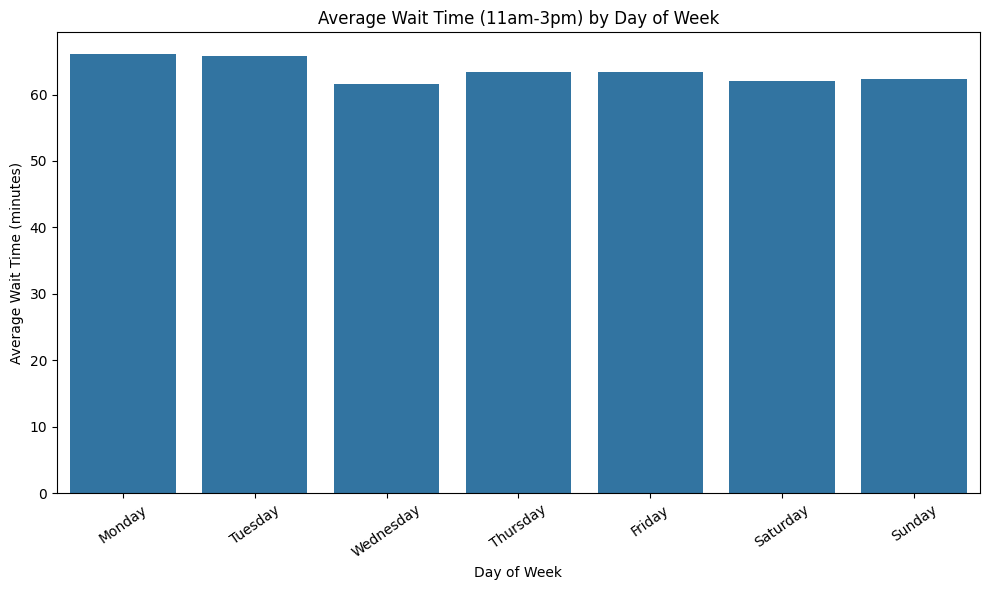

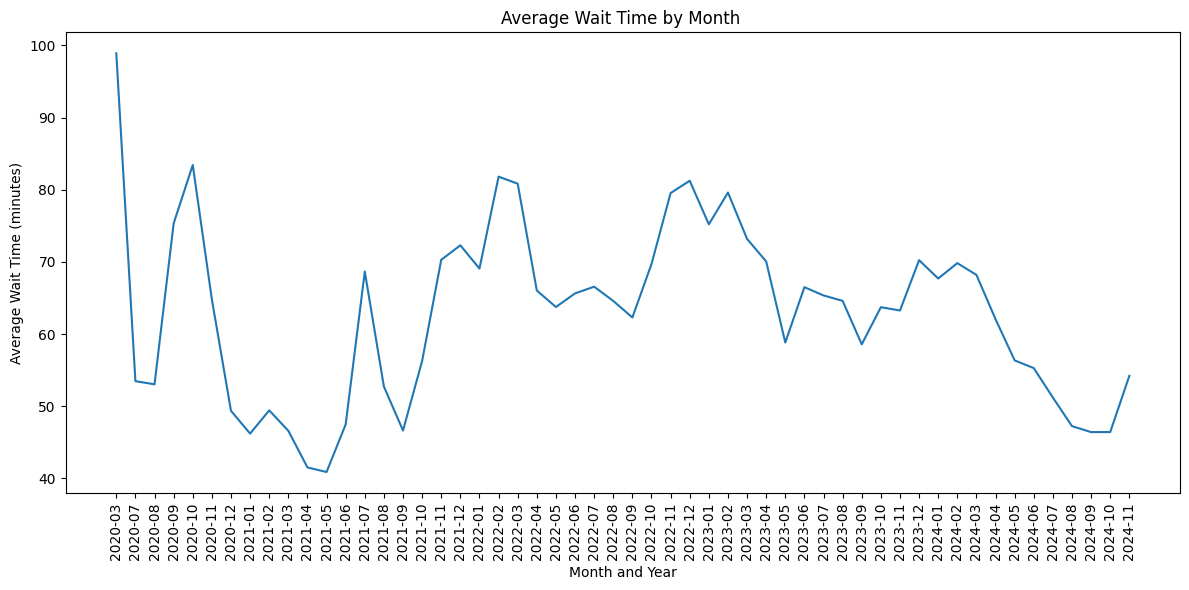

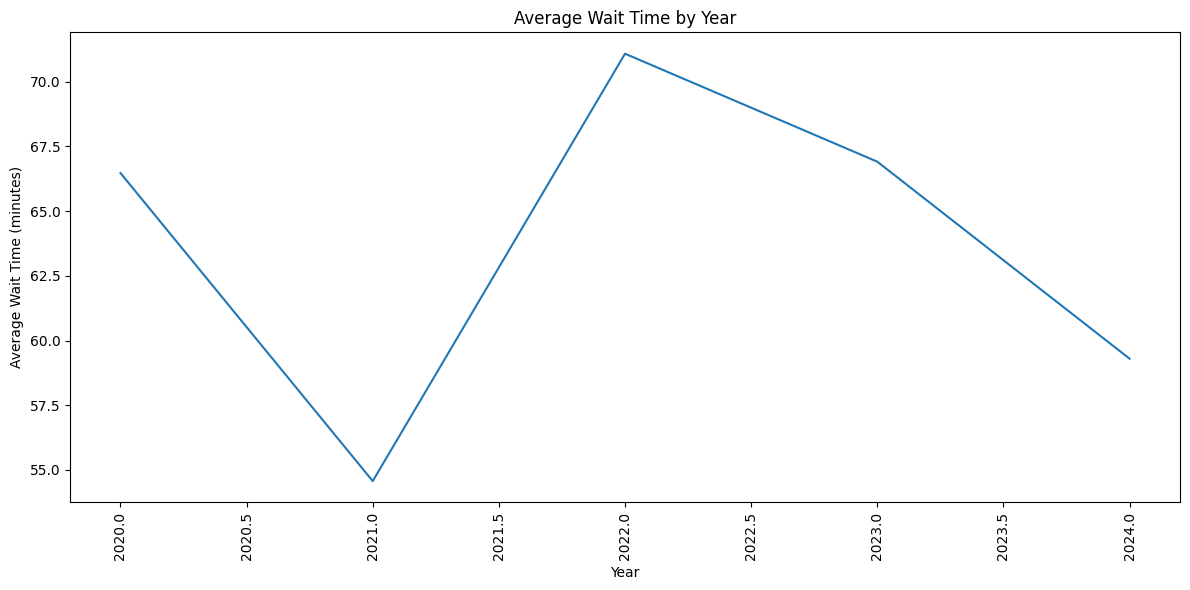

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 2 to 382
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   park_day          81 non-null     object 
 1   Day of Week       81 non-null     object 
 2   HS-Alien Saucers  81 non-null     float64
dtypes: float64(1), object(2)
memory usage: 3.0+ KB


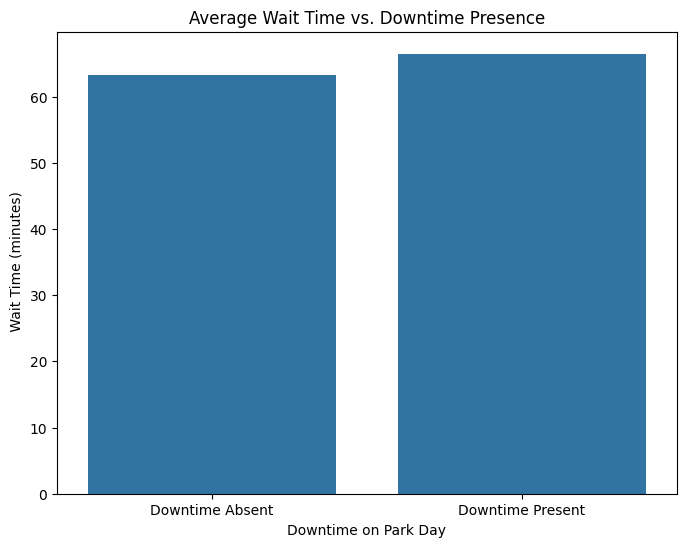

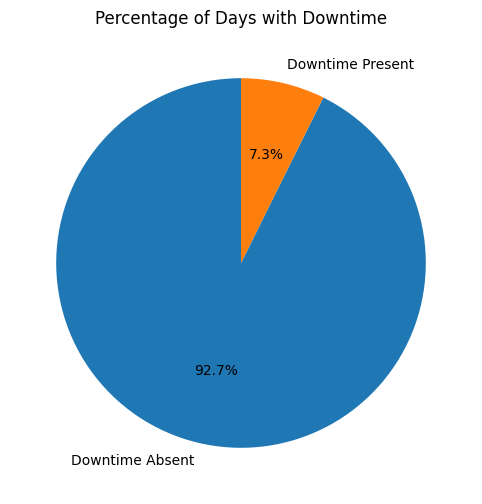

In [ ]:
eda('/content/MickeyMinnieRunawayRailway1_215_valid.xlsx')

<ipython-input-22-edabf6b3a514>:24: DtypeWarning: Columns (74,76,83,100,105,106,107,117,118,119,134,135,136,139,160,169,170,171,177,178,179,192,197,198,199,201,202,203,205,206,207,209,210,211,271,291,292,293,294) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv('/content/current_metatable.csv')


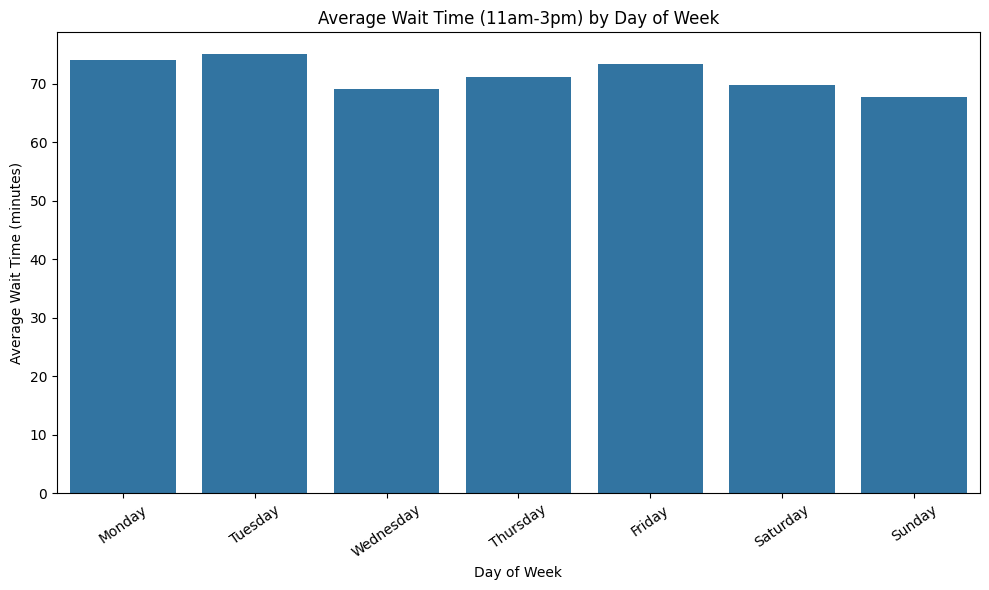

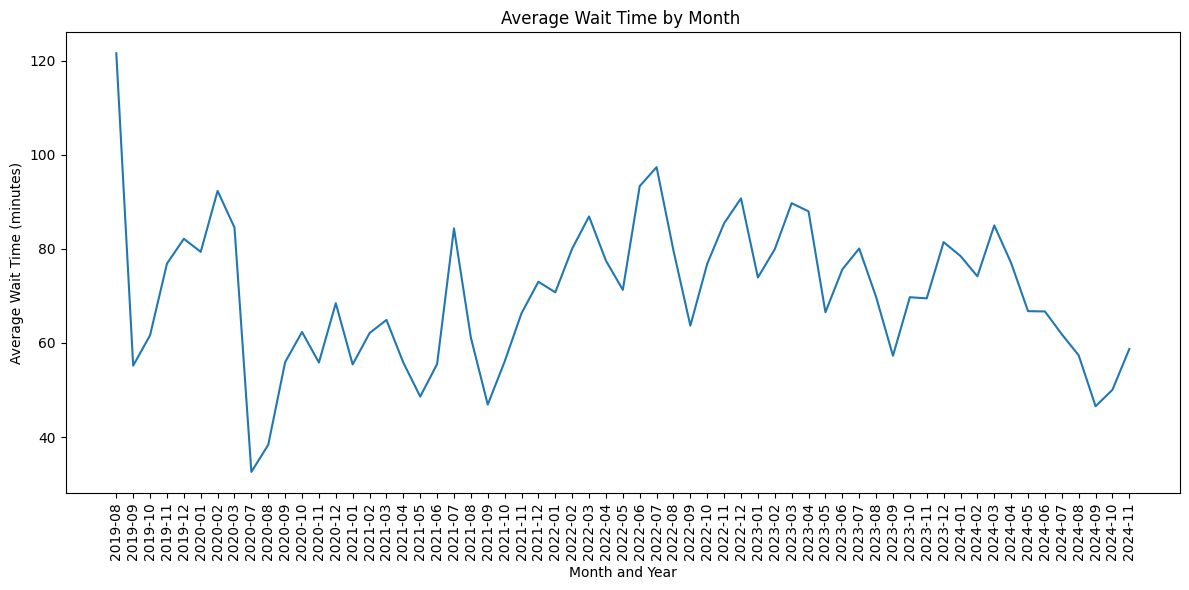

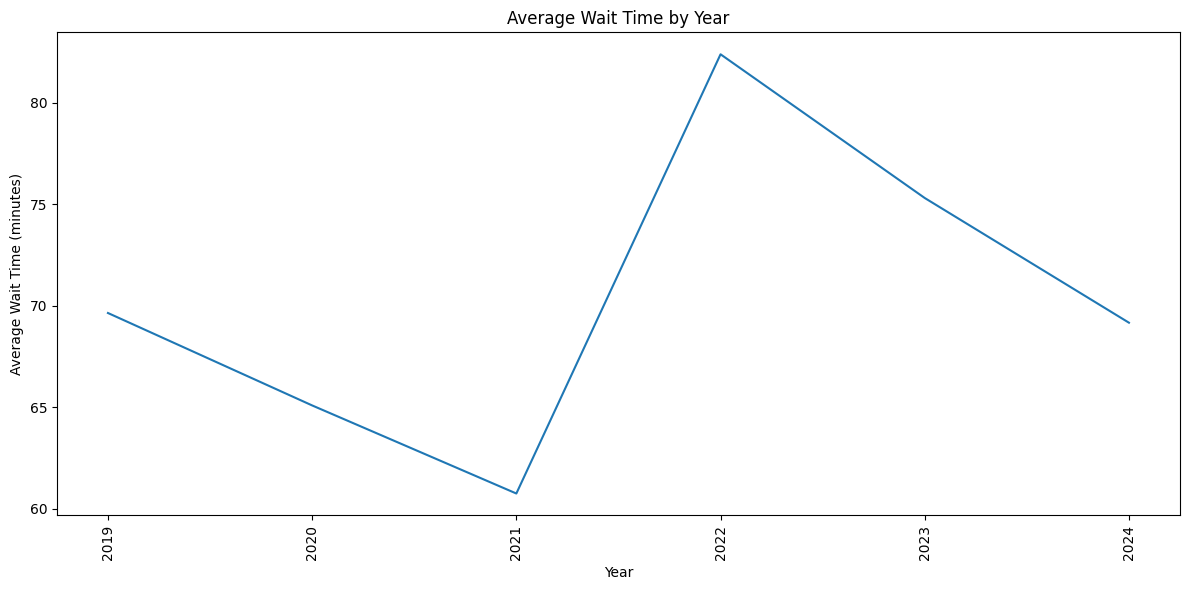

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 2 to 382
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   park_day          81 non-null     object 
 1   Day of Week       81 non-null     object 
 2   HS-Alien Saucers  81 non-null     float64
dtypes: float64(1), object(2)
memory usage: 3.0+ KB


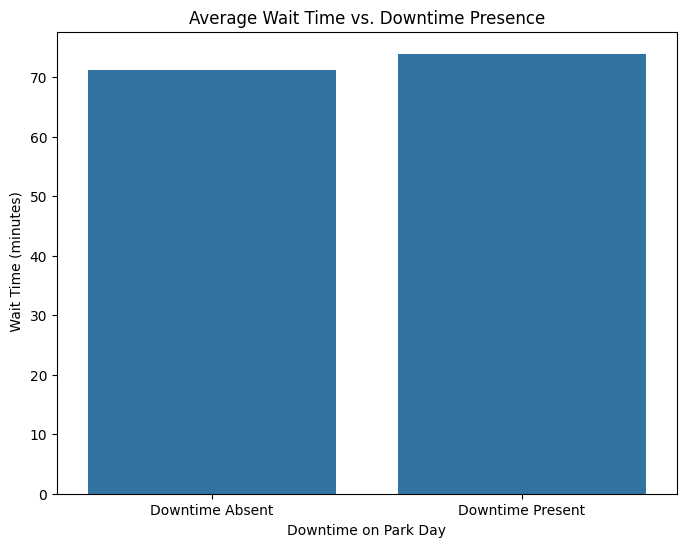

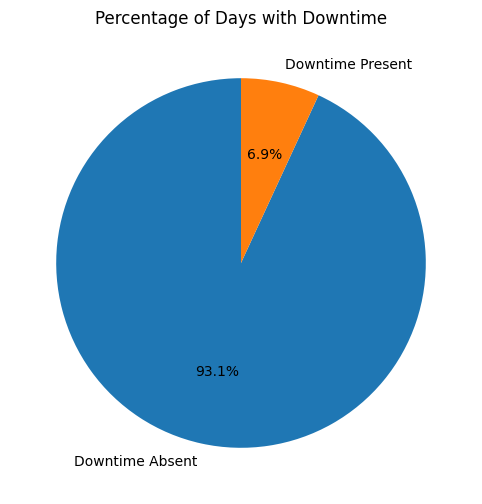

In [ ]:
eda('/content/MillenniumFalconSmugglersRun_215_valid.xlsx')